In [ ]:
import tensorflow as tf

In [2]:
print(tf.__version__)

2.17.0


In [3]:
fmnist=tf.keras.datasets.fashion_mnist
(training_images,training_labels),(test_images,test_labels)=fmnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


LABEL:3
IMAGE:
[[  0   0   0   0   0   0   0   0   0  73  64   0   0   0   0   0   0 123 112   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  65 211 221 226 208 178  97 119 198 207 221 221 218  56   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 159 229 201 211 229 240 236 230 225 211 209 205 229 145   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 173 216 204 211 210 217 218 215 212 212 210 207 221 192   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 193 222 196 215 210 205 208 207 210 212 213 205 223 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 199 230 198 195 215 211 211 210 211 213 201 222 224 204   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  10 213 231 209 198 217 212 212 213 214 217 200 222 225 213   5   0   0   0   0   0   0]
 [  0   0   0   0   0   0  33 221 221 163 218 214 212 214 213 216 214 214 187 224 219  32   0   0   0   0   0   0]
 [  0   0   0   0   0   0  47 224 219 143 224 210 214 214 212 217

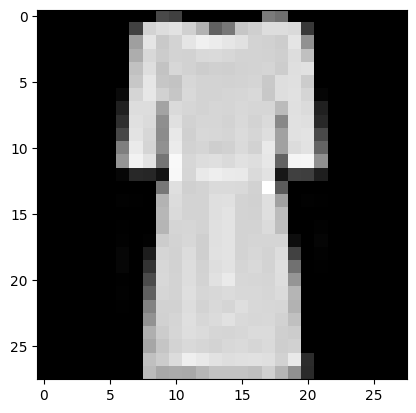

In [7]:
import numpy as np
import matplotlib.pyplot as plt
index=47
np.set_printoptions(linewidth=320)
print(f"LABEL:{training_labels[index]}")
print(f"IMAGE:\n{training_images[index]}")

plt.imshow(training_images[index],cmap='gray')
plt.show()

In [8]:
training_images=training_images/255.0
test_images=test_images/255.0

In [10]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [15]:
inputs = np.array([[1.0, 3.0, 2.0, 4.0]])
inputs = tf.convert_to_tensor(inputs)
print(f'input to softmax function: {inputs.numpy()}')

input to softmax function: [[1. 3. 2. 4.]]


In [16]:
outputs = tf.keras.activations.softmax(inputs)
print(f'output of softmax function: {outputs.numpy()}')

output of softmax function: [[0.0320586  0.23688282 0.08714432 0.64391426]]


In [17]:
sum = tf.reduce_sum(outputs)
print(f'sum of outputs: {sum}')

sum of outputs: 1.0


In [18]:
prediction = np.argmax(outputs)
print(f'class with highest probability: {prediction}')

class with highest probability: 3


In [19]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images,training_labels,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7928 - loss: 0.5853
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8650 - loss: 0.3658
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8771 - loss: 0.3292
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8897 - loss: 0.2981
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8953 - loss: 0.2815
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9000 - loss: 0.2671
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9043 - loss: 0.2519
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9095 - loss: 0.2383
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9106 - loss: 0.2355
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9161 - loss: 0.2225


In [20]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8860 - loss: 0.3373


[0.33205482363700867, 0.8883000016212463]

In [21]:
classifications = model.predict(test_images)
print(classifications[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[1.2814096e-10 6.1744304e-11 3.6763328e-10 4.0302616e-13 3.2008212e-11 8.6306878e-05 2.4210070e-10 6.8487838e-04 1.6179150e-09 9.9922872e-01]


In [22]:
print(test_labels[0])

9


In [23]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') >= 0.6): # Experiment with changing this value
      print("\nReached 60% accuracy so cancelling training!")
      self.model.stop_training = True

callbacks = myCallback()

fmnist = tf.keras.datasets.fashion_mnist
(training_images, training_labels) ,  (test_images, test_labels) = fmnist.load_data()

training_images=training_images/255.0
test_images=test_images/255.0
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(training_images, training_labels, epochs=5, callbacks=[callbacks])

Epoch 1/5
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7847 - loss: 0.5980
Reached 60% accuracy so cancelling training!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7847 - loss: 0.5978


In [24]:
import numpy as np

def american_put_binomial(S, K, T, r, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Initialize asset prices at maturity
    asset_prices = S * d ** np.arange(N, -1, -1) * u ** np.arange(0, N + 1)
    option_values = np.maximum(K - asset_prices, 0)  # Put payoff

    # Backward induction
    for i in range(N - 1, -1, -1):
        asset_prices = asset_prices[:-1] / d
        option_values = np.exp(-r * dt) * (p * option_values[1:] + (1 - p) * option_values[:-1])
        option_values = np.maximum(option_values, K - asset_prices)  # Early exercise

    return option_values[0]

# Example values
price = american_put_binomial(S=100, K=110, T=0.5, r=0.06, sigma=0.15, N=50)
print(f"American Put Price: ${price:.2f}")

American Put Price: $10.05
